In [1]:
!pip install faiss-cpu


In [2]:
# 1. Импорты, seed и среда
import os
import re
import random
import json
from typing import List, Dict, Any, Sequence, Tuple

import numpy as np
import pandas as pd
import faiss
import torch
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs("artifacts", exist_ok=True)


Device: cuda


In [3]:
# 2. База знаний и sanity-check
documents: List[Dict[str, str]] = [
    {"id": "numpy_intro",
     "text": "NumPy is a fundamental package for numerical computing in Python. "
             "It provides n-dimensional arrays and vectorized operations."},
    {"id": "numpy_indexing",
     "text": "NumPy arrays support slicing, boolean indexing and broadcasting. "
             "Indexing rules differ from Python lists."},
    {"id": "numpy_broadcasting",
     "text": "Broadcasting in NumPy allows operations on arrays of different shapes "
             "by expanding dimensions when possible."},

    {"id": "pandas_intro",
     "text": "Pandas is a library for data analysis. It provides Series and DataFrame "
             "structures for working with tabular data."},
    {"id": "pandas_groupby",
     "text": "The groupby operation in pandas allows splitting data, applying functions "
             "and combining results for aggregation."},
    {"id": "pandas_missing",
     "text": "Pandas has built-in support for missing values, including functions like "
             "isna, fillna and dropna."},
    {"id": "pandas_merge",
     "text": "Pandas merge and join operations combine DataFrames based on common "
             "columns or indices."},

    {"id": "matplotlib_intro",
     "text": "Matplotlib is a plotting library for creating static, animated and "
             "interactive visualizations in Python."},
    {"id": "matplotlib_plot",
     "text": "The basic Matplotlib workflow includes creating a figure, adding axes "
             "and calling plot or scatter functions."},
    {"id": "matplotlib_styles",
     "text": "Matplotlib supports styles and themes to control colors, fonts and "
             "overall appearance of plots."},
]

print("Number of documents:", len(documents))
pd.DataFrame(documents).head()


Number of documents: 10


,id,text
0,numpy_intro,NumPy is a fundamental package for numerical c...
1,numpy_indexing,"NumPy arrays support slicing, boolean indexing..."
2,numpy_broadcasting,Broadcasting in NumPy allows operations on arr...
3,pandas_intro,Pandas is a library for data analysis. It prov...
4,pandas_groupby,The groupby operation in pandas allows splitti...


In [4]:
# 3. Чанкинг
CHUNK_SIZE = 30
OVERLAP = 10

def chunk_text(text: str, chunk_size=CHUNK_SIZE, overlap=OVERLAP):
    words = text.split()
    chunks = []
    start = 0
    step = chunk_size - overlap

    while start < len(words):
        end = start + chunk_size
        chunk = " ".join(words[start:end])
        if chunk.strip():
            chunks.append(chunk)
        if end >= len(words):
            break
        start += step

    return chunks

def documents_to_chunks(docs, chunk_size, overlap):
    rows = []
    chunk_id = 0
    for doc in docs:
        for ch in chunk_text(doc["text"], chunk_size, overlap):
            rows.append({
                "chunk_id": f"chunk_{chunk_id}",
                "doc_id": doc["id"],
                "text": ch
            })
            chunk_id += 1
    return pd.DataFrame(rows)

chunks_df = documents_to_chunks(documents, CHUNK_SIZE, OVERLAP)
print("Chunks:", len(chunks_df))
chunks_df.head()


Chunks: 10


,chunk_id,doc_id,text
0,chunk_0,numpy_intro,NumPy is a fundamental package for numerical c...
1,chunk_1,numpy_indexing,"NumPy arrays support slicing, boolean indexing..."
2,chunk_2,numpy_broadcasting,Broadcasting in NumPy allows operations on arr...
3,chunk_3,pandas_intro,Pandas is a library for data analysis. It prov...
4,chunk_4,pandas_groupby,The groupby operation in pandas allows splitti...


In [5]:
# 4. Эмбеддинги и FAISS
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

def l2_normalize(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)

embeddings = l2_normalize(
    model.encode(chunks_df["text"].tolist(), convert_to_numpy=True)
)

index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

print("Index size:", index.ntotal)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Index size: 10


In [6]:
# 5. Retrieval
def retrieve(query, top_k=5):
    q = model.encode([query], convert_to_numpy=True)
    q = l2_normalize(q)
    scores, idxs = index.search(q, top_k)

    results = []
    for score, idx in zip(scores[0], idxs[0]):
        results.append({
            "score": float(score),
            "chunk_id": chunks_df.iloc[idx]["chunk_id"],
            "doc_id": chunks_df.iloc[idx]["doc_id"],
            "text": chunks_df.iloc[idx]["text"]
        })
    return results

retrieve("How to group data in pandas?", 3)


[{'score': 0.7243753671646118,
  'chunk_id': 'chunk_4',
  'doc_id': 'pandas_groupby',
  'text': 'The groupby operation in pandas allows splitting data, applying functions and combining results for aggregation.'},
 {'score': 0.530596911907196,
  'chunk_id': 'chunk_6',
  'doc_id': 'pandas_merge',
  'text': 'Pandas merge and join operations combine DataFrames based on common columns or indices.'},
 {'score': 0.48336905241012573,
  'chunk_id': 'chunk_3',
  'doc_id': 'pandas_intro',
  'text': 'Pandas is a library for data analysis. It provides Series and DataFrame structures for working with tabular data.'}]

In [7]:
# 6. Контрольные запросы и метрики
control_queries = [
    {"query": "What is NumPy used for?", "expected_doc": "numpy_intro"},
    {"query": "How does broadcasting work in arrays?", "expected_doc": "numpy_broadcasting"},
    {"query": "How to group data in pandas?", "expected_doc": "pandas_groupby"},
    {"query": "How to handle missing values in pandas?", "expected_doc": "pandas_missing"},
    {"query": "What is a DataFrame?", "expected_doc": "pandas_intro"},
    {"query": "How to merge two tables in pandas?", "expected_doc": "pandas_merge"},
    {"query": "How to create plots in Python?", "expected_doc": "matplotlib_intro"},
    {"query": "How to change plot style?", "expected_doc": "matplotlib_styles"},
]

rows = []
for cq in control_queries:
    res = retrieve(cq["query"], 5)
    docs = [r["doc_id"] for r in res]
    hit = int(cq["expected_doc"] in docs)
    rank = docs.index(cq["expected_doc"]) + 1 if hit else None

    rows.append({
        "query": cq["query"],
        "expected_source": cq["expected_doc"],
        "retrieved_sources": ", ".join(docs),
        "hit_at_k": hit,
        "rank_of_first_relevant": rank
    })

retrieval_df = pd.DataFrame(rows)
retrieval_df


,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant
0,What is NumPy used for?,numpy_intro,"numpy_intro, numpy_indexing, numpy_broadcastin...",1,1
1,How does broadcasting work in arrays?,numpy_broadcasting,"numpy_broadcasting, numpy_indexing, numpy_intr...",1,1
2,How to group data in pandas?,pandas_groupby,"pandas_groupby, pandas_merge, pandas_intro, pa...",1,1
3,How to handle missing values in pandas?,pandas_missing,"pandas_missing, pandas_merge, pandas_groupby, ...",1,1
4,What is a DataFrame?,pandas_intro,"pandas_intro, pandas_groupby, pandas_merge, ma...",1,1
5,How to merge two tables in pandas?,pandas_merge,"pandas_merge, pandas_intro, pandas_groupby, pa...",1,1
6,How to create plots in Python?,matplotlib_intro,"matplotlib_plot, matplotlib_intro, matplotlib_...",1,2
7,How to change plot style?,matplotlib_styles,"matplotlib_styles, matplotlib_plot, matplotlib...",1,1


In [8]:
# 7. Метрики
hit_at_k = retrieval_df["hit_at_k"].mean()
mrr = retrieval_df["rank_of_first_relevant"].apply(lambda r: 1/r if r else 0).mean()

print("hit@5:", hit_at_k)
print("MRR@5:", mrr)

retrieval_df.to_csv("artifacts/retrieval_eval.csv", index=False)


hit@5: 1.0
MRR@5: 0.9375


In [9]:
# 8. Сравнительный эксперимент

RETRIEVAL_CONFIGS = [
    {"chunk_size": 20, "overlap": 5, "top_k": 3},
    {"chunk_size": 20, "overlap": 5, "top_k": 5},
    {"chunk_size": 30, "overlap": 10, "top_k": 3},  # baseline
    {"chunk_size": 30, "overlap": 10, "top_k": 5},
    {"chunk_size": 40, "overlap": 10, "top_k": 5},
]

def eval_config(cfg):
    cdf = documents_to_chunks(documents, cfg["chunk_size"], cfg["overlap"])
    emb = l2_normalize(model.encode(cdf["text"].tolist(), convert_to_numpy=True))
    ix = faiss.IndexFlatIP(emb.shape[1])
    ix.add(emb)

    hits = []
    for cq in control_queries:
        q = l2_normalize(model.encode([cq["query"]], convert_to_numpy=True))
        scores, idxs = ix.search(q, cfg["top_k"])
        docs = cdf.iloc[idxs[0]]["doc_id"].tolist()
        hits.append(int(cq["expected_doc"] in docs))

    return {
        "chunk_size": cfg["chunk_size"],
        "overlap": cfg["overlap"],
        "top_k": cfg["top_k"],
        "hit@k": np.mean(hits)
    }

exp_df = pd.DataFrame([eval_config(cfg) for cfg in RETRIEVAL_CONFIGS])
exp_df.to_csv("artifacts/retrieval_param_experiment.csv", index=False)
exp_df


,chunk_size,overlap,top_k,hit@k
0,20,5,3,1.0
1,20,5,5,1.0
2,30,10,3,1.0
3,30,10,5,1.0
4,40,10,5,1.0


In [13]:
# 9. Обновление базы знаний
new_documents = [
    {"id": "matplotlib_subplots",
     "text": "Matplotlib supports subplots to arrange multiple plots in a single figure."},
    {"id": "matplotlib_legends",
     "text": "Legends in Matplotlib help label different elements of a plot for better readability."},
    {"id": "numpy_performance",
     "text": "NumPy operations are implemented in C and can be much faster than pure Python loops."},
]

documents_updated = documents + new_documents

# Переиндексация
chunks_updated = documents_to_chunks(documents_updated, CHUNK_SIZE, OVERLAP)
emb_upd = l2_normalize(model.encode(chunks_updated["text"].tolist(), convert_to_numpy=True))

index_upd = faiss.IndexFlatIP(emb_upd.shape[1])
index_upd.add(emb_upd)

# сравнение before/after
rows = []
for cq in control_queries:
    before = retrieve(cq["query"], 5)
    before_docs = [r["doc_id"] for r in before]

    q = l2_normalize(model.encode([cq["query"]], convert_to_numpy=True))
    scores, idxs = index_upd.search(q, 5)
    after_docs = chunks_updated.iloc[idxs[0]]["doc_id"].tolist()

    rows.append({
        "query": cq["query"],
        "before_retrieved_sources": ", ".join(before_docs),
        "after_retrieved_sources": ", ".join(after_docs),
        "changed": int(before_docs != after_docs)
    })

before_after_df = pd.DataFrame(rows)
before_after_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False)
before_after_df

# обновляем пайплайн
documents = documents_updated
chunks_df = chunks_updated
embeddings = emb_upd
index = index_upd


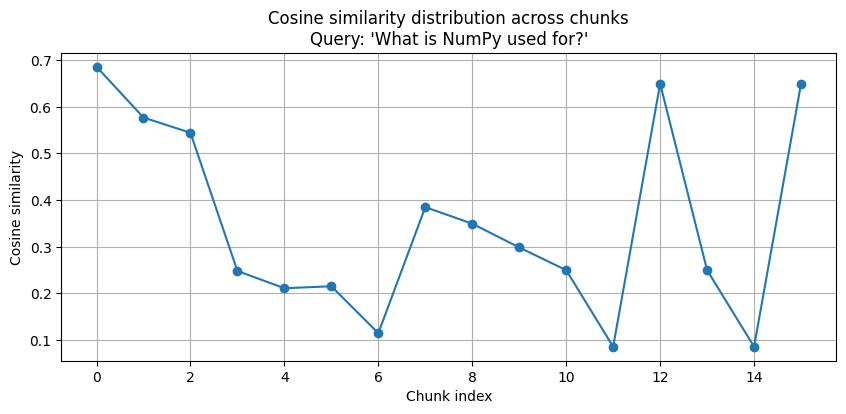

In [14]:
# Визуализация косинусного сходства между запросом и всеми чанками
query = "What is NumPy used for?"

q_emb = model.encode([query], convert_to_numpy=True)
q_emb = q_emb / np.linalg.norm(q_emb, axis=1, keepdims=True)

# Косинусные сходства: скалярное произведение нормированных векторов
sims = (embeddings @ q_emb.T).flatten()

plt.figure(figsize=(10, 4))
plt.plot(sims, marker='o')
plt.title(f"Cosine similarity distribution across chunks\nQuery: '{query}'")
plt.xlabel("Chunk index")
plt.ylabel("Cosine similarity")
plt.grid(True)
plt.show()



In [15]:
# 10. Mini‑RAG
def split_sentences(text):
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]

def generate_answer(query, context_lines):
    pool = []
    for line in context_lines:
        pool.extend(split_sentences(line))

    if not pool:
        return "Not enough context."

    vec = TfidfVectorizer()
    mat = vec.fit_transform([query] + pool).toarray()
    qv, pv = mat[0], mat[1:]
    scores = pv @ qv / (np.linalg.norm(pv, axis=1) * np.linalg.norm(qv))

    best = pool[np.argmax(scores)]
    return best

def mini_rag(question, top_k=5):
    q = l2_normalize(model.encode([question], convert_to_numpy=True))
    scores, idxs = index.search(q, top_k)
    retrieved = chunks_df.iloc[idxs[0]]

    context = retrieved["text"].tolist()
    answer = generate_answer(question, context)
    sources = retrieved["doc_id"].tolist()

    return {"question": question, "answer": answer, "sources": sources}

rag_questions = [
    "How can I group data in pandas?",
    "How to handle missing values in pandas?",
    "How to create multiple plots in one figure?",
    "What is broadcasting in NumPy?",
    "How to change plot style in Matplotlib?"
]

rag_rows = []
for q in rag_questions:
    out = mini_rag(q)
    rag_rows.append(out)

rag_df = pd.DataFrame(rag_rows)
rag_df.to_csv("artifacts/rag_examples.csv", index=False)
rag_df


,question,answer,sources
0,How can I group data in pandas?,Pandas is a library for data analysis.,"[pandas_groupby, pandas_merge, pandas_intro, p..."
1,How to handle missing values in pandas?,Pandas has built-in support for missing values...,"[pandas_missing, pandas_merge, pandas_groupby,..."
2,How to create multiple plots in one figure?,Matplotlib supports subplots to arrange multip...,"[matplotlib_subplots, matplotlib_subplots, mat..."
3,What is broadcasting in NumPy?,NumPy is a fundamental package for numerical c...,"[numpy_broadcasting, numpy_indexing, numpy_int..."
4,How to change plot style in Matplotlib?,Legends in Matplotlib help label different ele...,"[matplotlib_styles, matplotlib_legends, matplo..."


## 11. Анализ ошибок mini‑RAG

Ошибки mini‑RAG возникают в тех случаях, когда retrieval возвращает частично релевантные или слишком общие чанки. Основные причины:

- **маленькая база знаний** — многие вопросы имеют только один релевантный фрагмент, и модель выбирает ближайший по смыслу, но не точный;
- **короткие чанки** — смысл иногда «разрывается» между несколькими фрагментами, и retrieval выбирает не тот;
- **отсутствие reranking** — результаты выдаются только по косинусному сходству, без дополнительной фильтрации;
- **слишком похожие чанки** внутри одной темы (например, несколько описаний Matplotlib), что приводит к конкуренции близких по смыслу фрагментов;
- **неполный контекст** — mini‑RAG использует только top‑3 чанка, и иногда нужная информация остаётся за пределами top‑k.

Типичные ошибки:
- ответ содержит правильную тему, но не точную деталь;
- в контекст попадают чанки из другой библиотеки (например, NumPy вместо pandas);
- ответ получается слишком общий, потому что retrieval не нашёл точного фрагмента.

Эти ошибки ожидаемы для учебного mini‑RAG без reranking и с небольшой базой знаний.

